# Imports

In [15]:
import json
import copy
import tldextract
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import numpy as np

# Preprocessing

## Load in disputes-training.json

In [16]:
# load json
with open('disputes-training.json', 'r') as f:
    disputes = json.load(f)
    
# for each company compute average risk, make a df with company, count, # low, # med, # high, total risk, max, min, median, mean, std
disputes_df = pd.DataFrame(columns=['domain', 'total_count', 'num_low', 'num_med', 'num_high', 'total_risk', 'max_risk', 'min_risk', 'median_risk', 'mean_risk', 'std_risk'])
for domain in disputes:
    total_risk = 0
    count = 0
    risks = []
    for dispute in disputes[domain]:
        total_risk += disputes[domain][dispute]
        count += 1
        risks.append(disputes[domain][dispute])
    avg_risk = total_risk / count if count > 0 else 0
    disputes_df = pd.concat([disputes_df, pd.DataFrame([{'domain': domain, 'total_count': count, 'num_low': sum(1 for r in risks if r == 1), 'num_med': sum(1 for r in risks if r == 2), 'num_high': sum(1 for r in risks if r == 3), 'total_risk': total_risk, 'max_risk': max(risks) if risks else 0, 'min_risk': min(risks) if risks else 0, 'median_risk': pd.Series(risks).median() if risks else 0, 'mean_risk': pd.Series(risks).mean() if risks else 0, 'std_risk': pd.Series(risks).std() if risks else 0}])], ignore_index=True)
disputes_df.head()

C:\Users\andre\AppData\Local\Temp\ipykernel_2740\2251541619.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  disputes_df = pd.concat([disputes_df, pd.DataFrame([{'domain': domain, 'total_count': count, 'num_low': sum(1 for r in risks if r == 1), 'num_med': sum(1 for r in risks if r == 2), 'num_high': sum(1 for r in risks if r == 3), 'total_risk': total_risk, 'max_risk': max(risks) if risks else 0, 'min_risk': min(risks) if risks else 0, 'median_risk': pd.Series(risks).median() if risks else 0, 'mean_risk': pd.Series(risks).mean() if risks else 0, 'std_risk': pd.Series(risks).std() if risks else 0}])], ignore_index=True)


,domain,total_count,num_low,num_med,num_high,total_risk,max_risk,min_risk,median_risk,mean_risk,std_risk
0,microsoft.com,11,10,1,0,12,2,1,1.0,1.090909,0.301511
1,libertymutual.com,21,20,1,0,22,2,1,1.0,1.047619,0.218218
2,advanceautoparts.com,39,34,5,0,44,2,1,1.0,1.128205,0.338688
3,allstate.com,23,23,0,0,23,1,1,1.0,1.000000,0.000000
4,centerpointenergy.com,54,45,8,1,64,3,1,1.0,1.185185,0.437578


## Load companies-training.jsonl

In [17]:
# load json
with open('companies-training.jsonl', 'r') as f:
    companies = [json.loads(line) for line in f]
companies_df = pd.DataFrame(companies)
companies_df.head()

,company,domain,naics_sector,market_value,security_analysts_est,assets,popularity,osint_domains
0,Advance Auto Parts,advanceautoparts.com,Retail Trade,7208.0,2.208686,12018.5,23937,1
1,Alaska Air Group,alaskaair.com,Transportation and Warehousing,5348.0,3.857078,14186.0,11264,4
2,Allstate,allstate.com,Finance and Insurance,26919.0,259.371504,97957.0,6297,19
3,American Express,americanexpress.com,Finance and Insurance,130357.0,211.777389,228354.0,1261,47
4,Bank of America,bankofamerica.com,Finance and Insurance,234293.0,1303.349786,3051375.0,766,225


## Combine both DFs

In [18]:
final_df = pd.merge(companies_df, disputes_df, left_on='domain', right_on='domain', how='left')
final_df.head()

,company,domain,naics_sector,market_value,security_analysts_est,assets,popularity,osint_domains,total_count,num_low,num_med,num_high,total_risk,max_risk,min_risk,median_risk,mean_risk,std_risk
0,Advance Auto Parts,advanceautoparts.com,Retail Trade,7208.0,2.208686,12018.5,23937,1,39,34,5,0,44,2,1,1.0,1.128205,0.338688
1,Alaska Air Group,alaskaair.com,Transportation and Warehousing,5348.0,3.857078,14186.0,11264,4,18,14,4,0,22,2,1,1.0,1.222222,0.427793
2,Allstate,allstate.com,Finance and Insurance,26919.0,259.371504,97957.0,6297,19,23,23,0,0,23,1,1,1.0,1.000000,0.000000
3,American Express,americanexpress.com,Finance and Insurance,130357.0,211.777389,228354.0,1261,47,7,5,1,1,10,3,1,1.0,1.428571,0.786796
4,Bank of America,bankofamerica.com,Finance and Insurance,234293.0,1303.349786,3051375.0,766,225,38,21,15,2,57,3,1,1.0,1.500000,0.604040


# Statistics

## Risk Details

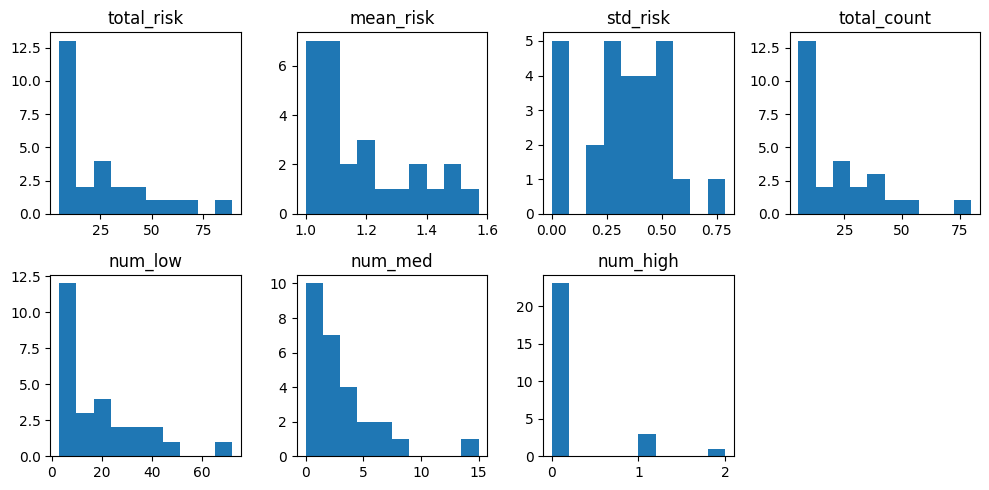

In [19]:
# plot histograms of total risk, mean risk, std risk, total count, low, med, high
risk_columns = ['total_risk', 'mean_risk', 'std_risk', 'total_count', 'num_low', 'num_med', 'num_high']
plt.figure(figsize=(10, 5))
for i, col in enumerate(risk_columns):
    plt.subplot(2, 4, i + 1)
    plt.hist(final_df[col].dropna(), bins=10)
    plt.title(col)
plt.tight_layout()
plt.show()

## Risk vs Industry

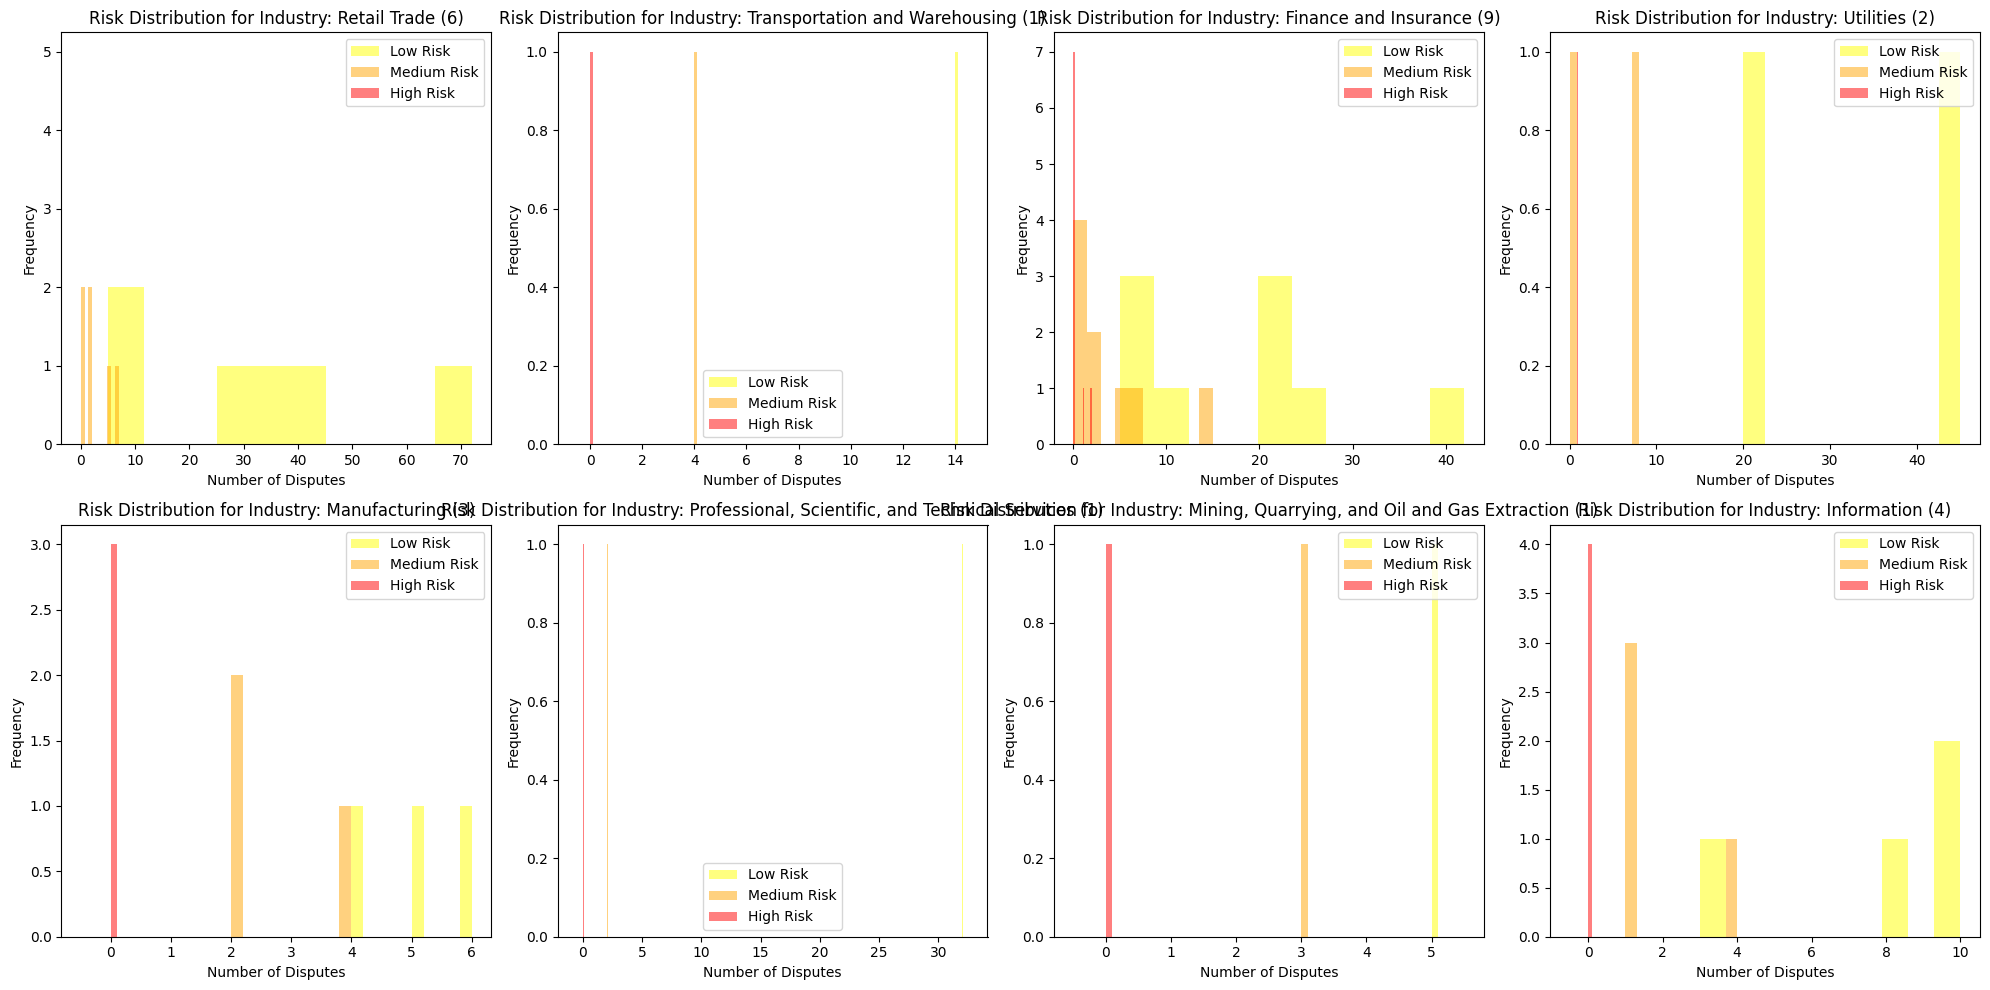

In [20]:
# group by industry and for each industry, plot overlapping histograms of num_low, num_med, num_high
industries = final_df['naics_sector'].unique()
rows = 2
cols = 4
fig, axes = plt.subplots(rows, cols, figsize=(20, 10))
axes = axes.flatten()

for i, industry in enumerate(industries):
    ax = axes[i]
    industry_df = final_df[final_df['naics_sector'] == industry]

    ax.hist(industry_df['num_low'].dropna(), bins=10, alpha=0.5, color='yellow', label='Low Risk')
    ax.hist(industry_df['num_med'].dropna(), bins=10, alpha=0.5, color='orange', label='Medium Risk')
    ax.hist(industry_df['num_high'].dropna(), bins=10, alpha=0.5, color='red', label='High Risk')

    ax.set_title(f'Risk Distribution for Industry: {industry} ({len(industry_df)})')
    ax.set_xlabel('Number of Disputes')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()


## Risk Attribtues vs Company Attributes

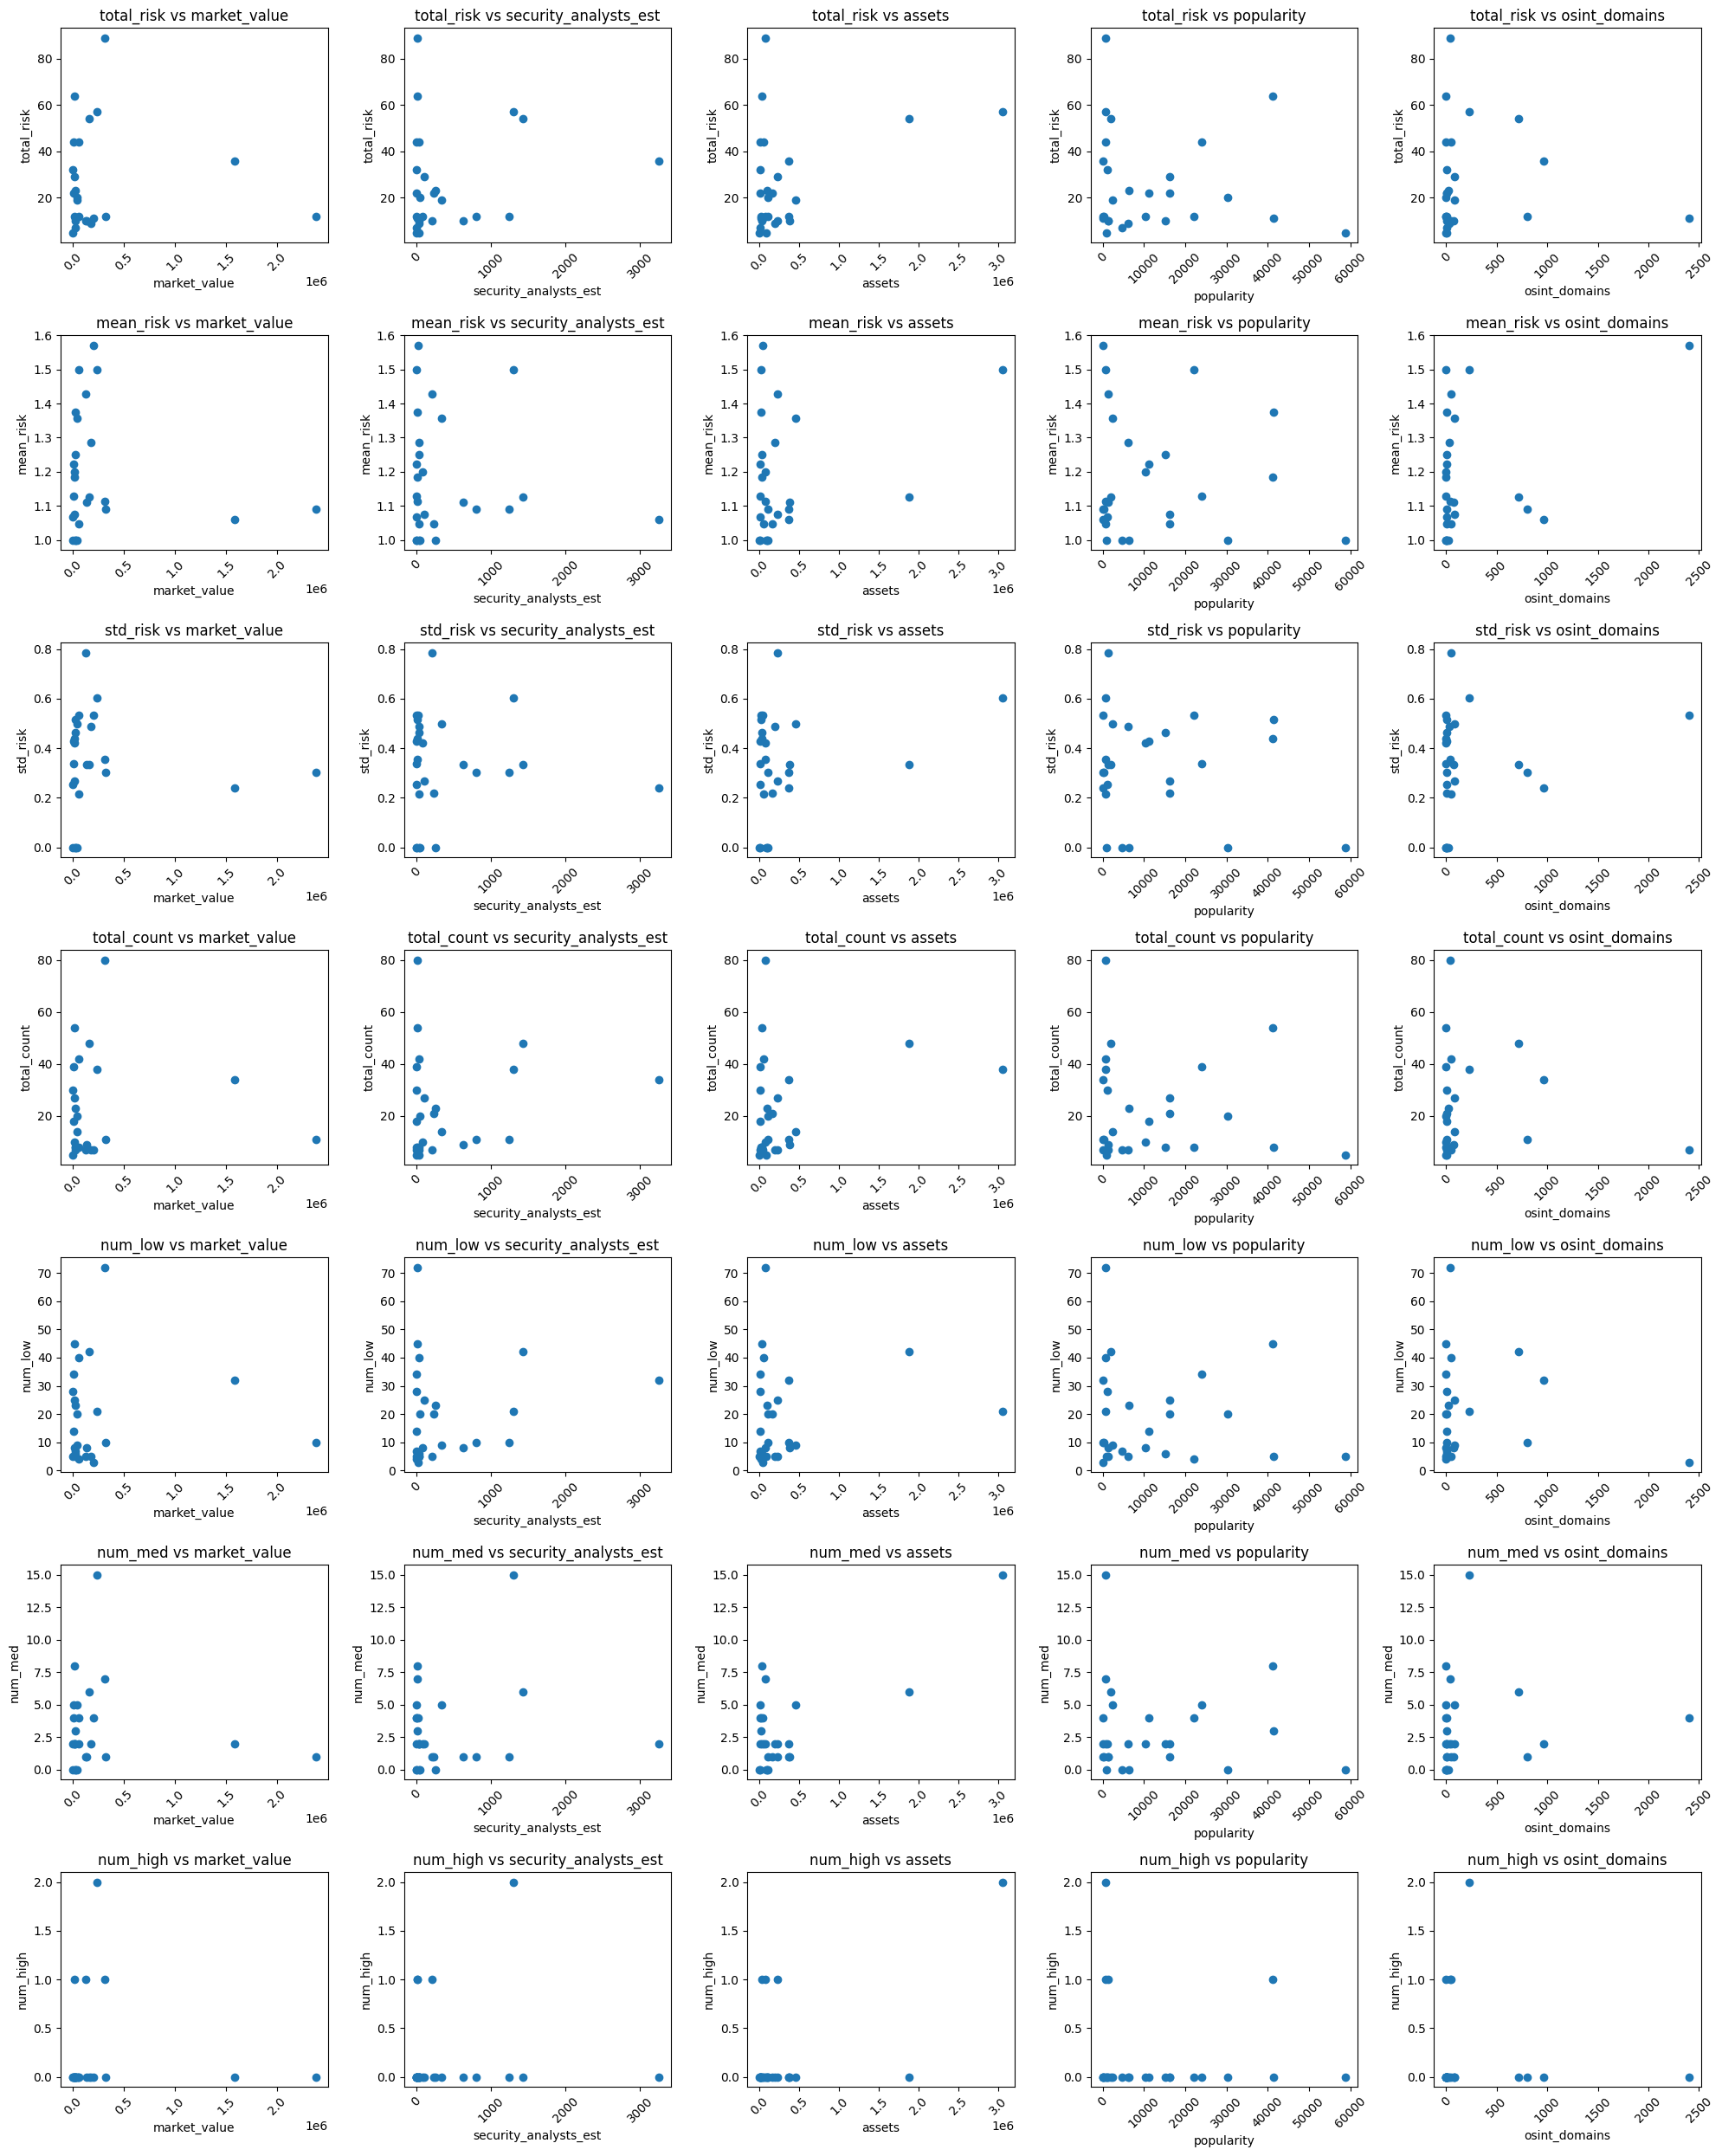

In [28]:
# plot risk attributes against company attributes
risk_columns = ['total_risk', 'mean_risk', 'std_risk', 'total_count', 'num_low', 'num_med', 'num_high']
company_attributes = ['market_value', 'security_analysts_est', 'assets', 'popularity', 'osint_domains']
plt.figure(figsize=(20, 25))
for i, risk_col in enumerate(risk_columns):
    for j, company_col in enumerate(company_attributes):
        plt.subplot(len(risk_columns), len(company_attributes), i * len(company_attributes) + j + 1)
        plt.scatter(final_df[company_col], final_df[risk_col])
        plt.title(f'{risk_col} vs {company_col}')
        plt.xlabel(company_col)
        plt.ylabel(risk_col)
        plt.xticks(rotation=45)
plt.tight_layout()